# HOUSE PRICE PREDICTION
# Dataset: King County, Seattle - Kaggle
# Improvements after Andrew Ng Course 1

# STEP 1 - IMPORT LIBRARIES

In [21]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures

# STEP 2 - LOAD DATASET

In [5]:
houses = pd.read_csv("dataset/kc_house_data.csv")

# STEP 3 - EXPLORATORY DATA ANALYSIS (EDA)
# 3.1 - Check shape, info, describe

In [6]:
houses.head()
houses.describe()
houses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

# 3.2 - Check null values

In [7]:
print(houses.isnull().sum())
print("\nTotal missing values:", houses.isnull().sum().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Total missing values: 0


# STEP 4 - DATA CLEANING

Dataset has no missing values — verified above ✅

# STEP 5 - DATA VISUALIZATION
# 5.1 - Correlation Heatmap

In [8]:
houses.dtypes
houses_nodate = houses.drop(columns = 'date')

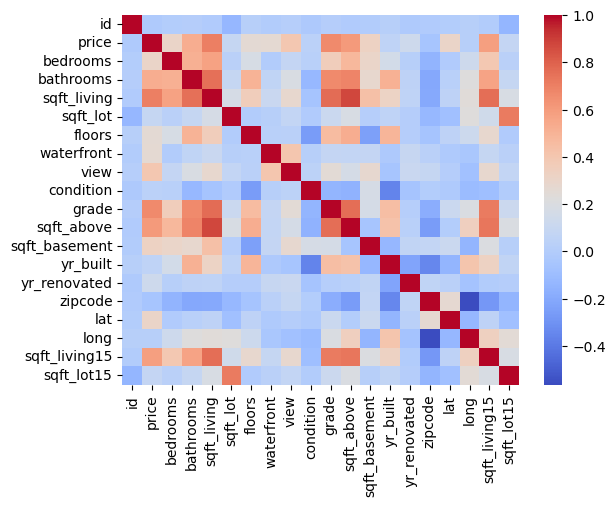

In [9]:
sns.heatmap(houses_nodate.corr(),cmap = 'coolwarm')
plt.show()

# 5.2 - Scatter plot (sqft_living vs price)

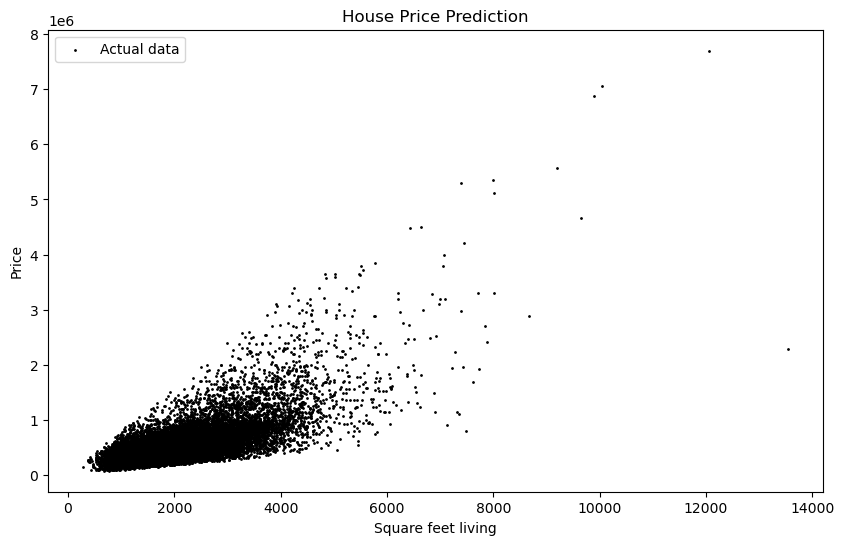

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(houses['sqft_living'],houses['price'] , 
            color='black', s=1, label='Actual data')
plt.xlabel('Square feet living')
plt.ylabel('Price')
plt.title('House Price Prediction')
plt.legend()
plt.show()

# STEP 6 - FEATURE ENGINEERING

In [11]:
# 1. House age
max_year = houses['yr_built'].max()
houses['house_age'] = max_year - houses['yr_built']

# 2. Was it renovated?
houses['is_renovated'] = (houses['yr_renovated'] > 0).astype(int)

# 3. Total rooms
houses['bed_bath_rooms'] = houses['bedrooms'] + houses['bathrooms']

# 4. Sqft ratio
houses['sqft_ratio'] = houses['sqft_living'] / houses['sqft_lot']

# STEP 7 - FEATURE SELECTION

In [13]:
selected_features = ['sqft_living', 'bedrooms', 'bathrooms',
                     'view', 'grade', 'floors', 'waterfront',
                     'condition', 'lat', 'sqft_living15',
                     'house_age', 'is_renovated',
                     'bed_bath_rooms', 'sqft_ratio']
X = houses[selected_features]
Y= houses['price']

# STEP 8 - TRAIN TEST SPLIT

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# STEP 9 - Feature Scaling
# 9.1 - StandardScaler

In [37]:
scaler = StandardScaler()
X_train_data = scaler.fit_transform(X_train)
X_test_data  = scaler.transform(X_test)
X_train_standard_scaled = pd.DataFrame(X_train_data,columns=X_train.columns)
X_test_standard_scaled = pd.DataFrame(X_test_data,columns=X_test.columns)

# 9.2 - RobustScaler

In [35]:
scaler = RobustScaler()
X_train_data = scaler.fit_transform(X_train)
X_test_data  = scaler.transform(X_test)
X_train_robust_scaled = pd.DataFrame(X_train_data,columns=X_train.columns)
X_test_robust_scaled = pd.DataFrame(X_test_data,columns=X_test.columns)

# 9.3 - ColumnTransformer (mixed)

In [36]:
outlier_features = ['bedrooms', 'sqft_living', 
                    'bed_bath_rooms', 'sqft_ratio']

normal_features  = ['waterfront', 'is_renovated',
                    'view', 'condition', 'grade',
                    'floors', 'lat', 'sqft_living15',
                    'bathrooms', 'house_age']
all_features = outlier_features + normal_features

X_train_column_scaled= pd.DataFrame(
    ct.fit_transform(X_train), 
    columns=all_features)

X_test_column_scaled = pd.DataFrame(
    ct.transform(X_test), 
    columns=all_features)

# STEP 10 - PHASE 1: FIND BEST SCALER
# Using Linear Regression with all 3 scalers
# 10.1 - Linear Regression with StandardScaler

In [41]:
lr_standard = LinearRegression()
lr_standard.fit(X_train_standard_scaled, y_train)
lr_standard_pred = lr_standard.predict(X_test_standard_scaled)

# 10.2 - Linear Regression with RobustScaler

In [44]:
lr_robust = LinearRegression()
lr_robust.fit(X_train_robust_scaled, y_train)
lr_robust_pred = lr_robust.predict(X_test_robust_scaled)

# 10.3 - Linear Regression with ColumnTransformer

In [45]:
lr_column= LinearRegression()
lr_column.fit(X_train_column_scaled, y_train)
lr_column_pred = lr_column.predict(X_test_column_scaled)

# 10.4 - Compare R2 scores → pick best scaler

In [54]:
print("\nRMSE Comparison:")
print("=" * 50)
rmse_models = {
    'Linear Regression Standard Scaled' : root_mean_squared_error(y_test, lr_standard_pred),
    'Linear Regression Robust Scaled'   : root_mean_squared_error(y_test, lr_robust_pred),
    'Linear Regression column Scaled'   : root_mean_squared_error(y_test, lr_column_pred)
}

for model_name, rmse in rmse_models.items():
    print(f"{model_name:<35} {rmse:.2f}")
print("=" * 50)

print("R2 Comparison:")
print("=" * 50)
r2_models = {
'Linear Regression Standard Scaled' : r2_score(y_test, lr_standard_pred),
'Linear Regression Robust Scaled'   : r2_score(y_test, lr_robust_pred),
'Linear Regression Column Scaled'   : r2_score(y_test, lr_column_pred)
}
for model_name, score in r2_models.items():
    print(f"{model_name:<35} {score:.4f}")
print("=" * 50)



RMSE Comparison:
Linear Regression Standard Scaled   200961.27
Linear Regression Robust Scaled     200961.27
Linear Regression column Scaled     200961.27
R2 Comparison:
Linear Regression Standard Scaled   0.7107
Linear Regression Robust Scaled     0.7107
Linear Regression Column Scaled     0.7107


# Simple Linear Regression

In [55]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print(root_mean_squared_error(y_test, lr_pred))
print(r2_score(y_test, lr_pred))


200961.26745443625
0.7107230715566994


# Step 10 findings markdown:
"Linear Regression is scale invariant
All scalers gave same R2: 0.7107
# Proceeding with StandardScaler"

# STEP 11 - PHASE 2: MODEL BUILDING
# Using StandardScaler (best from Phase 1)

# 11.1 - Linear Regression 

In [56]:
lr = LinearRegression()
lr.fit(X_train_standard_scaled, y_train)
lr_pred = lr.predict(X_test_standard_scaled)

# 11.2 - Ridge Regression

In [59]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_standard_scaled, y_train)
ridge_pred = ridge.predict(X_test_standard_scaled)

# 11.3 - Lasso Regression

In [61]:
lasso = Lasso(alpha=1.0 ,max_iter = 100000)
lasso.fit(X_train_standard_scaled, y_train)
lasso_pred = lasso.predict(X_test_standard_scaled)

# 11.4 - Polynomial Regression with degree - 2

In [66]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_standard_scaled)
X_test_poly  = poly.transform(X_test_standard_scaled)

poly_model_degree2 = LinearRegression()
poly_model_degree2.fit(X_train_poly, y_train)
poly_pred_degree2 = poly_model_degree2.predict(X_test_poly)

# 11.5 - Polynomial Regression with degree - 3

In [68]:
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train_standard_scaled)
X_test_poly  = poly.transform(X_test_standard_scaled)

poly_model_degree3 = LinearRegression()
poly_model_degree3.fit(X_train_poly, y_train)
poly_pred_degree3 = poly_model_degree3.predict(X_test_poly)

# STEP 12 - MODEL EVALUATION
# 12.1 - R2 Score comparison table
# 12.2 - RMSE comparison table

In [78]:
print("R2 Comparison:")
print("=" * 50)
r2_models = {
    'Linear Regression'               : r2_score(y_test, lr_pred),
    'Ridge Regression'                : r2_score(y_test, ridge_pred),
    'Lasso Regression'                : r2_score(y_test, lasso_pred),
    'Polynomial Regression Degree-2'  : r2_score(y_test, poly_pred_degree2),
    'Polynomial Regression Degree-3'  : r2_score(y_test, poly_pred_degree3)
}
for model_name, score in r2_models.items():
    print(f"{model_name:<35} {score:.4f}")
print("=" * 50)

print("\nRMSE Comparison:")
print("=" * 50)
rmse_models = {
    
    'Linear Regression'             : root_mean_squared_error(y_test, lr_pred),
    'Ridge Regression'              : root_mean_squared_error(y_test, ridge_pred),
    'Lasso Regression'              : root_mean_squared_error(y_test, lasso_pred),
    'Polynomial Regression Degree-2': root_mean_squared_error(y_test, poly_pred_degree2),
    'Polynomial Regression Degree-3': root_mean_squared_error(y_test, poly_pred_degree3)
}

for model_name, rmse in rmse_models.items():
    print(f"{model_name:<35} {rmse:.2f}")
print("=" * 50)

R2 Comparison:
Linear Regression                   0.7107
Ridge Regression                    0.7107
Lasso Regression                    0.7107
Polynomial Regression Degree-2      0.7847
Polynomial Regression Degree-3      0.6383

RMSE Comparison:
Linear Regression                   200961.27
Ridge Regression                    200961.08
Lasso Regression                    200961.28
Polynomial Regression Degree-2      173390.72
Polynomial Regression Degree-3      224717.48


# STEP 13 - FEATURE IMPORTANCE ANALYSIS

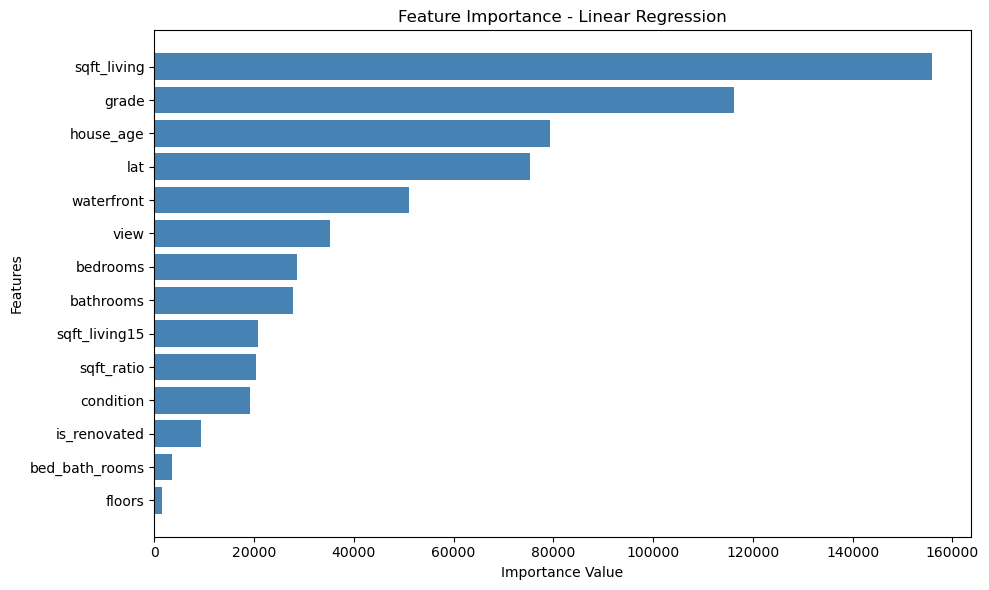

In [73]:
# Get coefficients from linear model
feature_importance = pd.Series(
    lr_standard.coef_,
    index=selected_features
).abs().sort_values(ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.index, 
         feature_importance.values,
         color='steelblue')

plt.xlabel('Importance Value')
plt.ylabel('Features')
plt.title('Feature Importance - Linear Regression')
plt.tight_layout()
plt.show()

## STEP 14 - CONCLUSIONS

### 14.1 - Phase 1 Finding
Linear Regression is scale invariant.
All 3 scalers gave same R2: 0.7107
StandardScaler selected as it is industry standard.

### 14.2 - Best Scaler
StandardScaler is selected as best scaler.
All 3 scalers gave same results for Linear Regression.

### 14.3 - Best Model
Polynomial Regression Degree 2 is the best model.

### 14.4 - Results Summary

| Model                     | R2 Score | RMSE       |
|---------------------------|----------|------------|
| Linear Regression         | 0.7107   | 200,961    |
| Ridge Regression          | 0.7107   | 200,961    |
| Lasso Regression          | 0.7107   | 200,961    |
| Polynomial Degree 2       | 0.7847   | 173,390    |
| Polynomial Degree 3       | 0.6383   | 224,717    |

### 14.5 - Improvement Over Basic Notebook

| | R2 Score | RMSE |
|---|---|---|
| Basic Notebook    | 0.6935 | 210,255 |
| Improved Notebook | 0.7847 | 173,390 |
| Improvement       | +0.091 | -36,865 |

### 14.6 - Overfitting Observation
Polynomial Degree 2 → R2: 0.7847 (sweet spot ✅)
Polynomial Degree 3 → R2: 0.6383 (overfitting starts ❌)
Higher degrees increase overfitting!
Degree 2 is the sweet spot!

### 14.7 - Key Features From Importance Plot
1. sqft_living  → most important feature
2. grade        → second most important
3. house_age    → engineered feature worked! ✅
4. lat          → location affects price
5. waterfront   → waterfront houses cost more
6. floors       → least important feature

### 14.8 - Future Improvements
- Will try Random Forest after Andrew Ng Course 2
- Will try XGBoost after Andrew Ng Course 2
- Target R2 → 0.85+
- Will tune hyperparameters